In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

master_df = pd.read_csv("/content/drive/MyDrive/ADSProject/Project_Root/Final_Cleaned_Dataset/master_df.csv")

#EDA

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


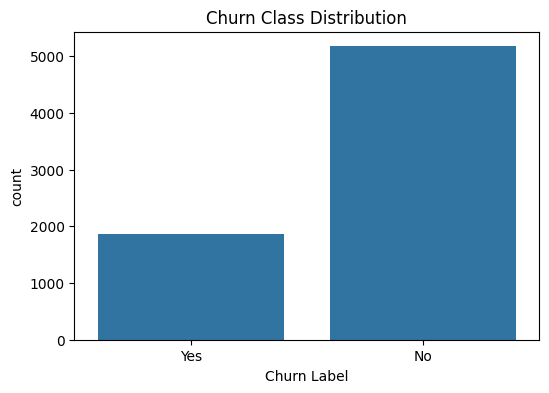

In [25]:
# Class Balance - Churn

import matplotlib.pyplot as plt
import seaborn as sns

print(master_df["Churn Label"].value_counts())
print("\nPercentage:")
print(master_df["Churn Label"].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=master_df, x="Churn Label")
plt.title("Churn Class Distribution")
plt.show()

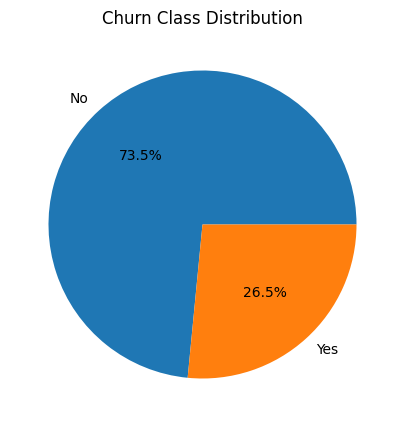

In [26]:
master_df["Churn Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(5,5)
)
plt.title("Churn Class Distribution")
plt.ylabel("")
plt.show()

Feature Frequency Distributions

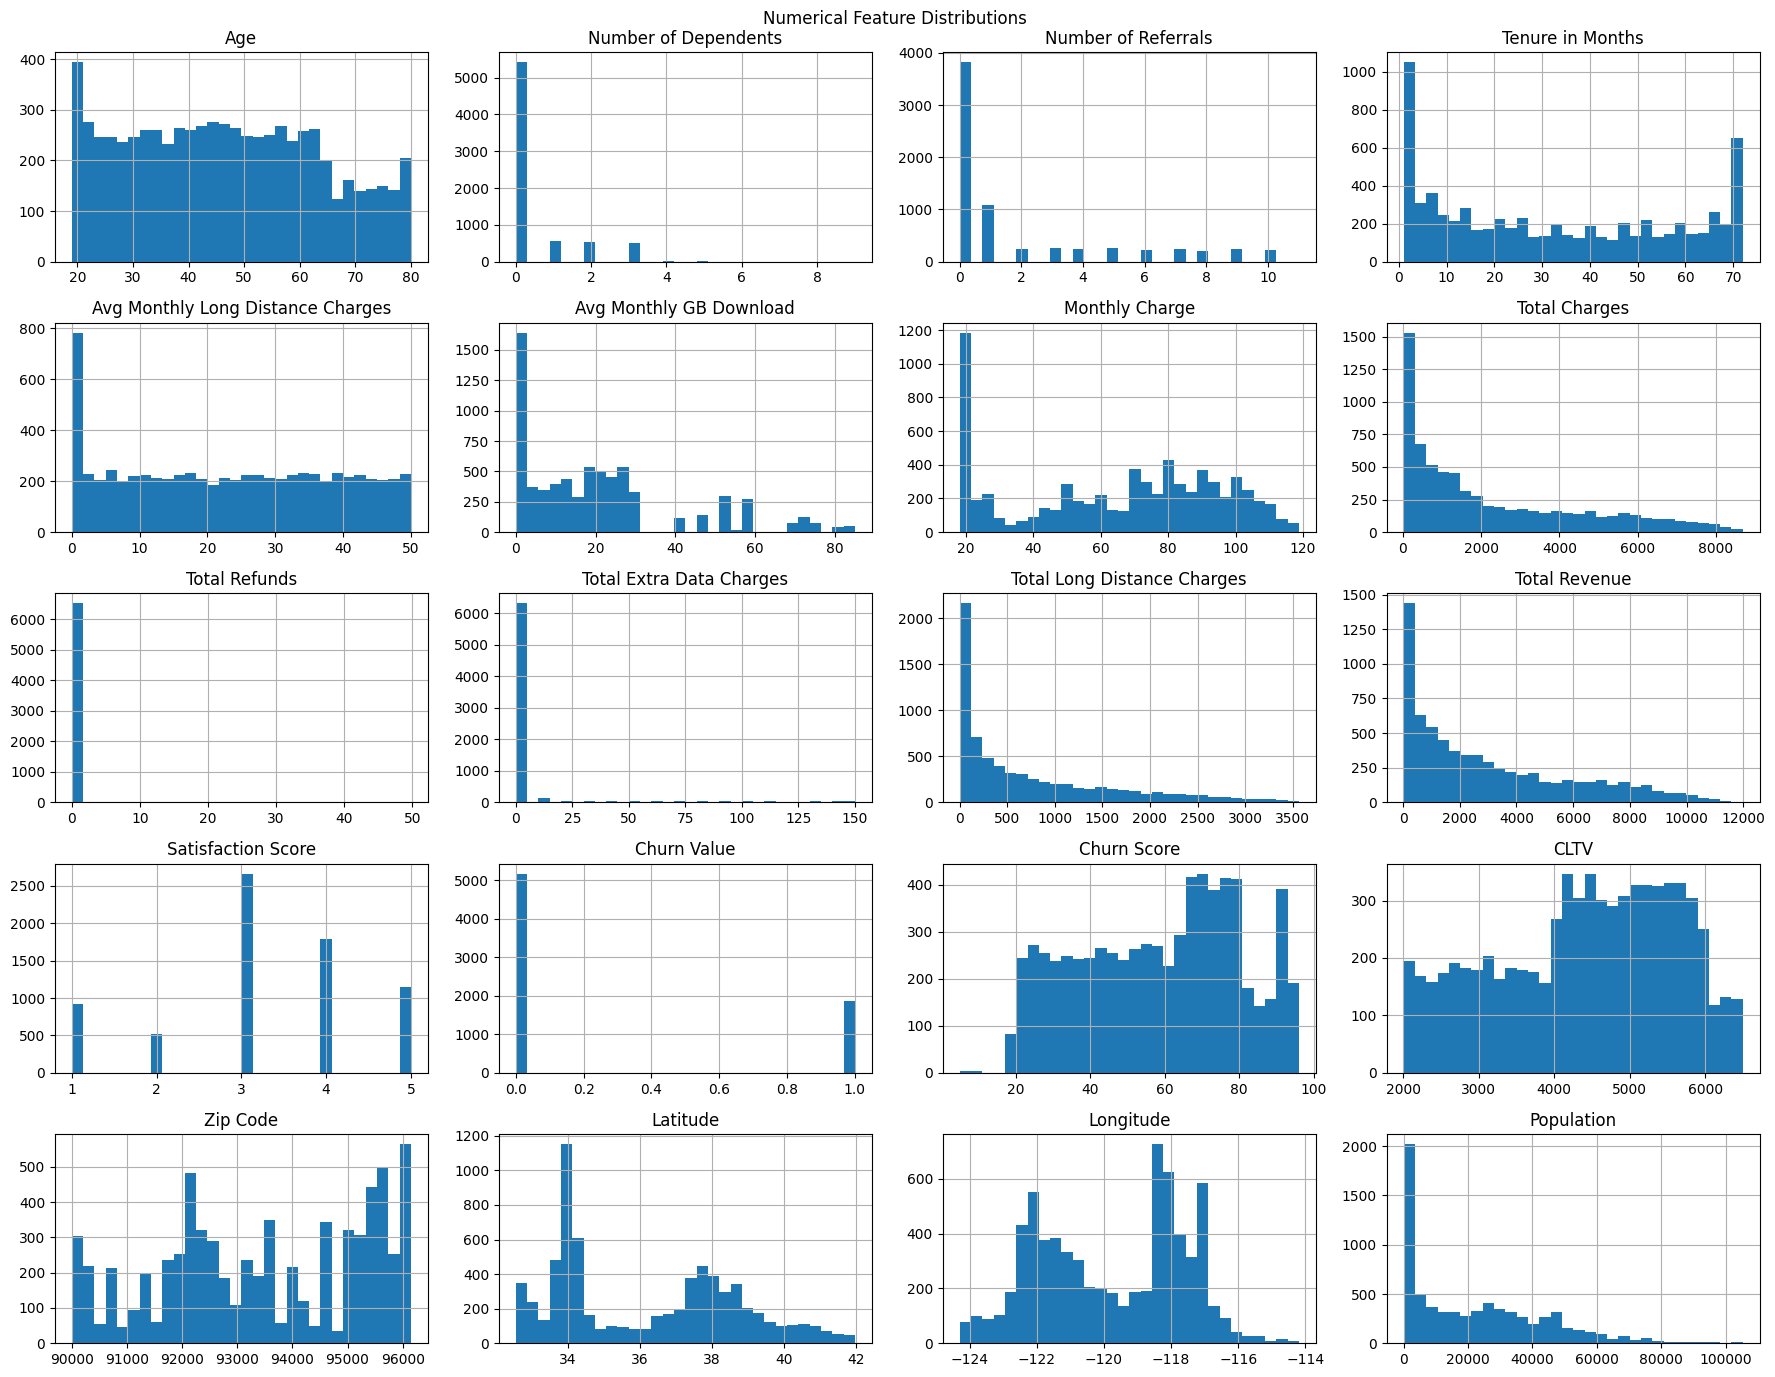

In [27]:
# Numerical Features - Histogram

numeric_cols = master_df.select_dtypes(include="number").columns

master_df[numeric_cols].hist(
    figsize=(18,14),
    bins=30
)

plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

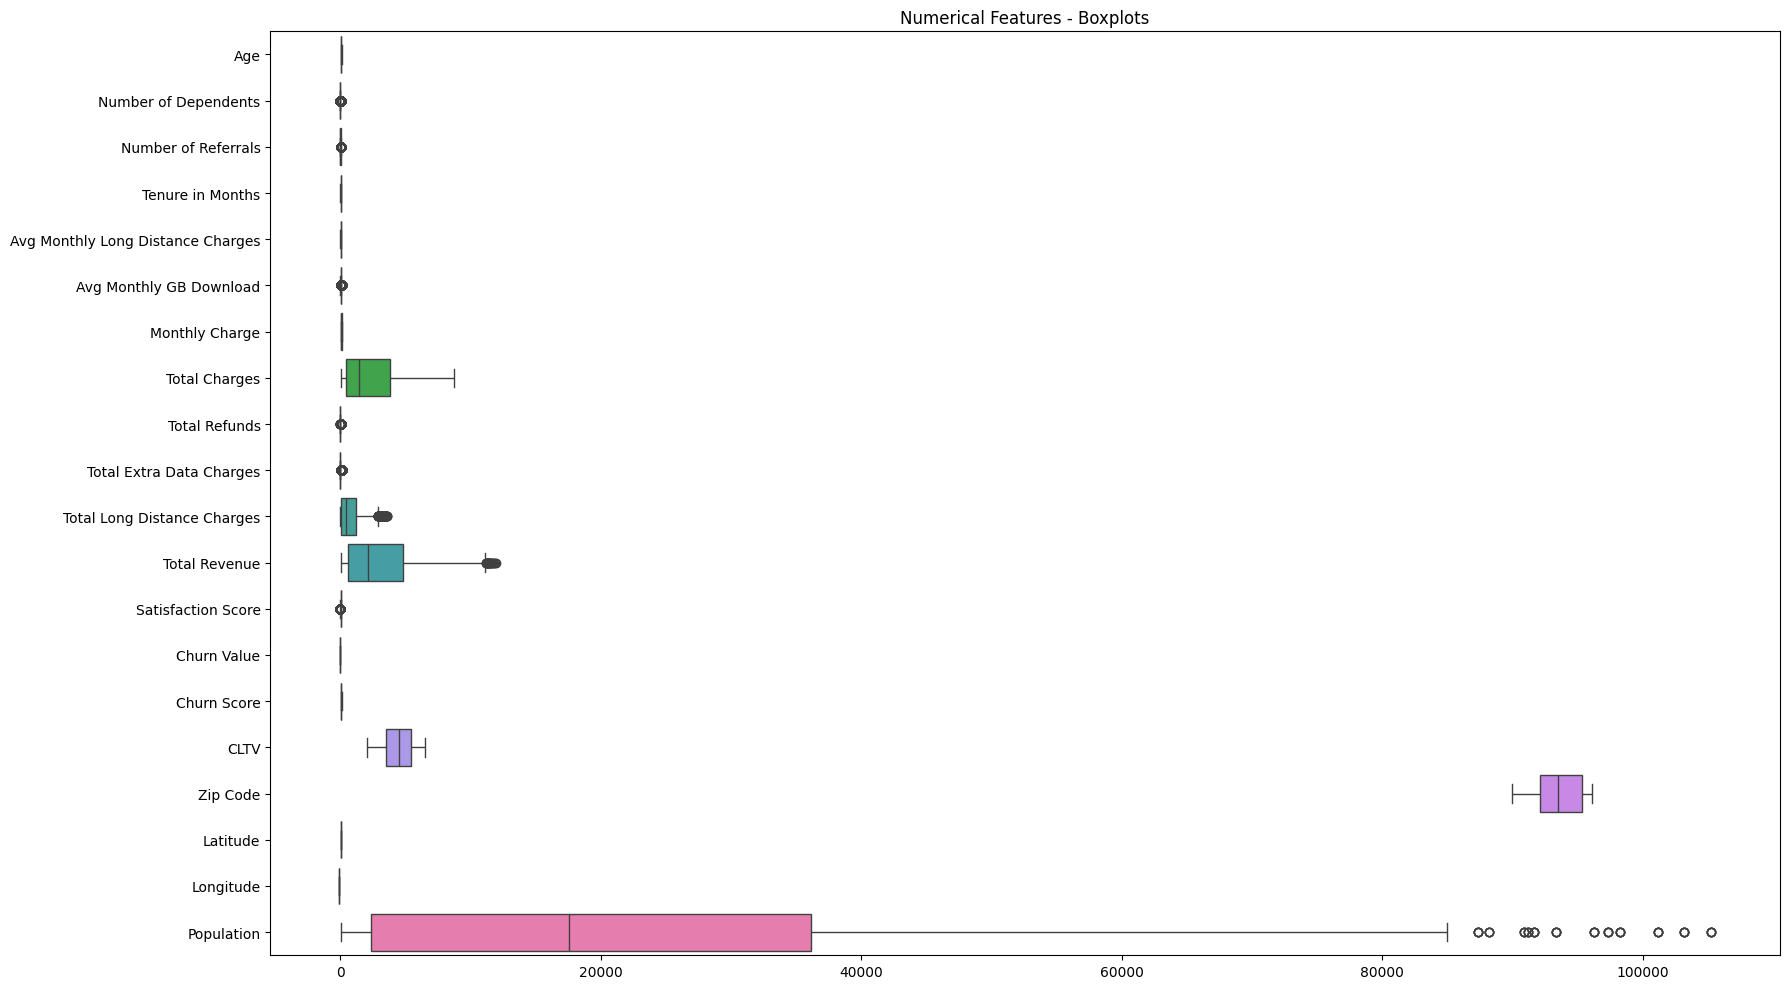

In [28]:
# Box Plot - Outlier Detection

plt.figure(figsize=(18,10))

sns.boxplot(
    data=master_df[numeric_cols],
    orient="h"
)

plt.title("Numerical Features - Boxplots")
plt.tight_layout()
plt.show()

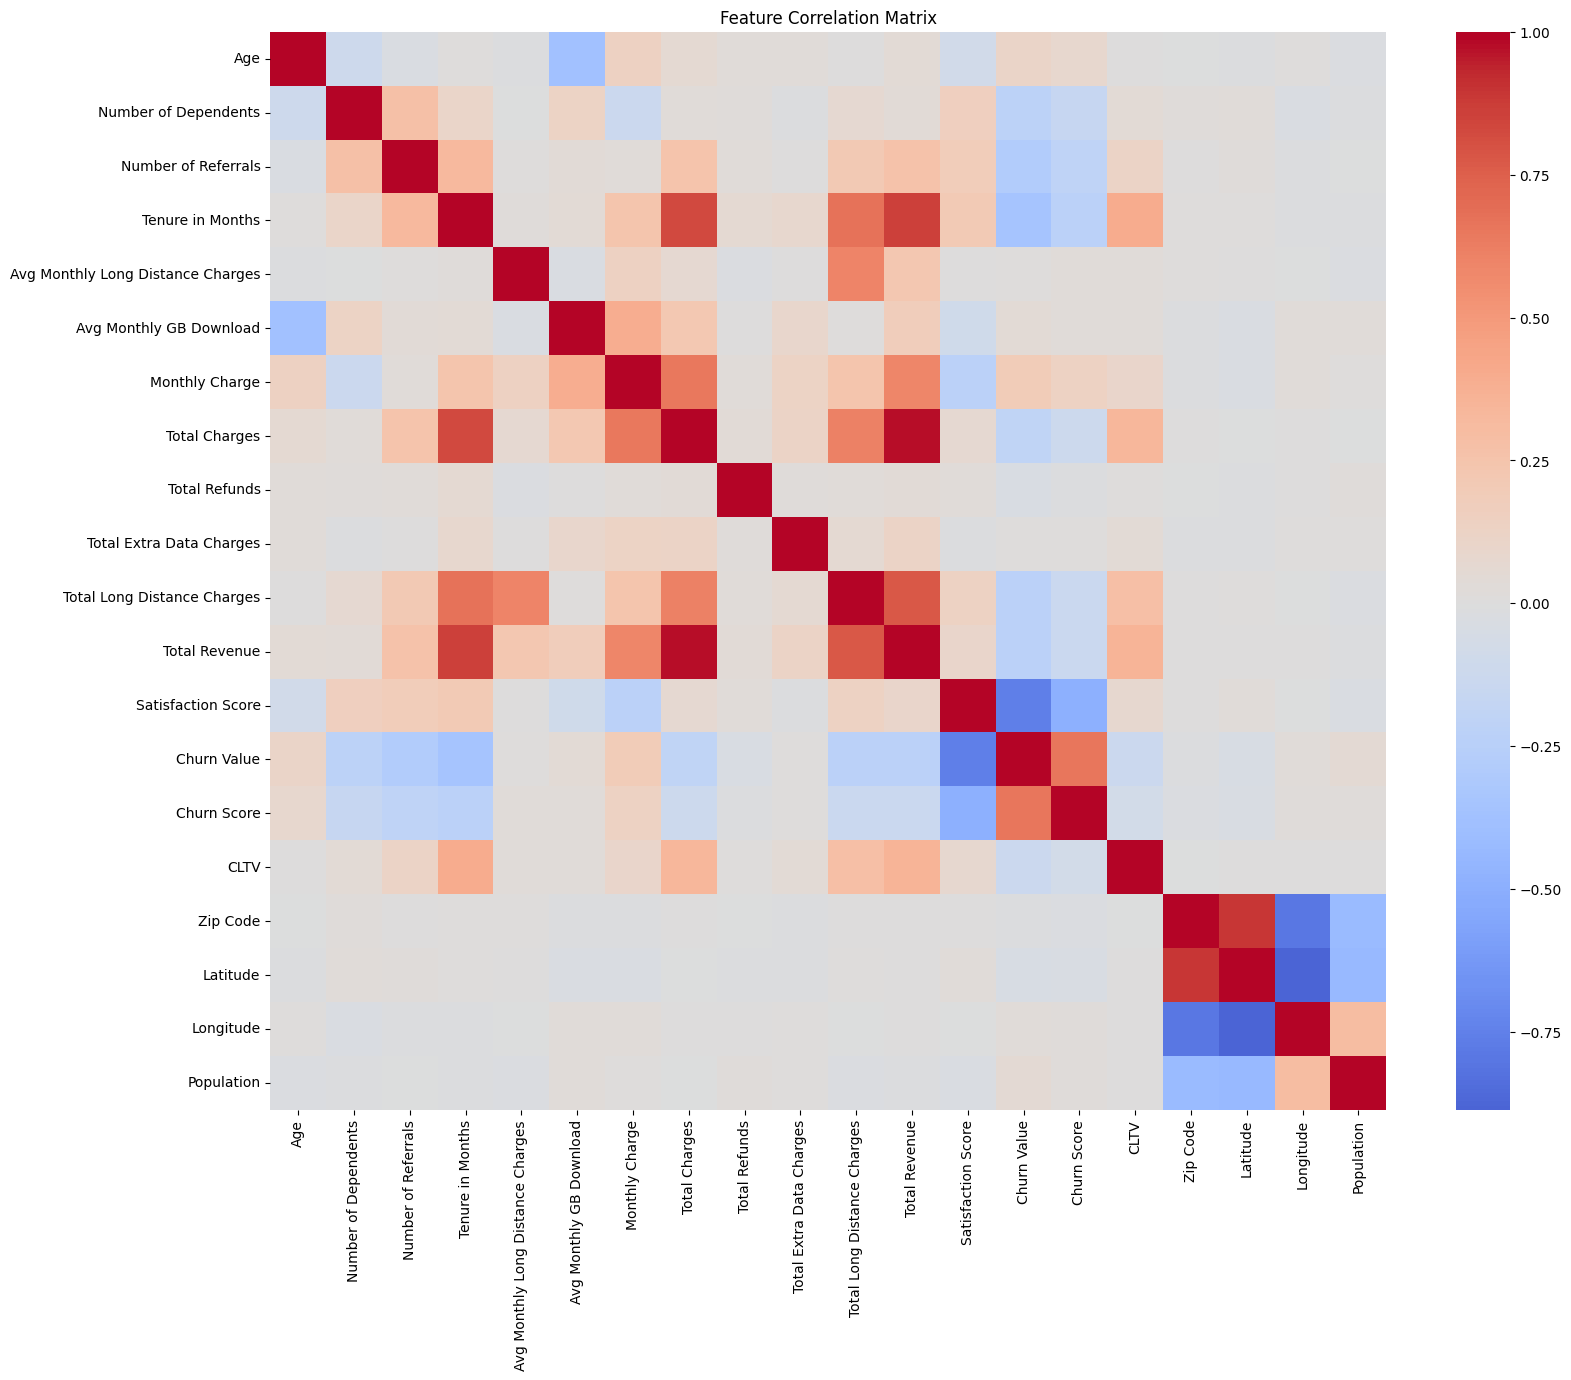

In [29]:
# Feature Corelation- Heatmap

plt.figure(figsize=(18,14))

corr = master_df[numeric_cols].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [30]:
# Strongest Corelation

corr_pairs = (
    corr.where(~corr.eq(1))
        .stack()
        .sort_values(key=abs, ascending=False)
)

corr_pairs.head(20)

,,0
Total Revenue,Total Charges,0.972212
Total Charges,Total Revenue,0.972212
Latitude,Zip Code,0.894769
Zip Code,Latitude,0.894769
Latitude,Longitude,-0.885979
Longitude,Latitude,-0.885979
Total Revenue,Tenure in Months,0.853146
Tenure in Months,Total Revenue,0.853146
Total Charges,Tenure in Months,0.826074
Tenure in Months,Total Charges,0.826074


In [31]:
# Statistical SUmmary

master_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,7043.0,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
Number of Dependents,7043.0,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
Number of Referrals,7043.0,1.951867,3.001199,0.000000,0.000000,0.000000,3.000000,11.000000
Tenure in Months,7043.0,32.386767,24.542061,1.000000,9.000000,29.000000,55.000000,72.000000
Avg Monthly Long Distance Charges,7043.0,22.958954,15.448113,0.000000,9.210000,22.890000,36.395000,49.990000
Avg Monthly GB Download,7043.0,20.515405,20.418940,0.000000,3.000000,17.000000,27.000000,85.000000
Monthly Charge,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Total Charges,7043.0,2280.381264,2266.220462,18.800000,400.150000,1394.550000,3786.600000,8684.800000
Total Refunds,7043.0,1.962182,7.902614,0.000000,0.000000,0.000000,0.000000,49.790000
Total Extra Data Charges,7043.0,6.860713,25.104978,0.000000,0.000000,0.000000,0.000000,150.000000


In [32]:
# Count Ourtliers using IQR

outlier_summary = []

for col in numeric_cols:
    Q1 = master_df[col].quantile(0.25)
    Q3 = master_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((master_df[col] < lower) | (master_df[col] > upper)).sum()

    outlier_summary.append([
        col,
        count,
        round(count / len(master_df) * 100, 2)
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Outlier Count", "Outlier %"]
).sort_values("Outlier %", ascending=False)

outlier_df

,Feature,Outlier Count,Outlier %
1,Number of Dependents,1627,23.10
12,Satisfaction Score,922,13.09
9,Total Extra Data Charges,728,10.34
2,Number of Referrals,676,9.60
8,Total Refunds,525,7.45
5,Avg Monthly GB Download,362,5.14
10,Total Long Distance Charges,196,2.78
19,Population,57,0.81
11,Total Revenue,21,0.30
0,Age,0,0.00


In [33]:
# Distribution Type - Skewness

distribution_summary = pd.DataFrame({
    "Mean": master_df[numeric_cols].mean(),
    "Median": master_df[numeric_cols].median(),
    "Std": master_df[numeric_cols].std(),
    "Skewness": master_df[numeric_cols].skew(),
    "Kurtosis": master_df[numeric_cols].kurtosis()
}).sort_values("Skewness", key=abs, ascending=False)

distribution_summary

,Mean,Median,Std,Skewness,Kurtosis
Total Refunds,1.962182,0.000000,7.902614,4.328517,18.350658
Total Extra Data Charges,6.860713,0.000000,25.104978,4.091209,16.458874
Number of Dependents,0.468692,0.000000,0.962802,2.109932,4.446358
Number of Referrals,1.951867,0.000000,3.001199,1.446060,0.721964
Total Long Distance Charges,749.099262,401.440000,846.660055,1.238282,0.644092
Avg Monthly GB Download,20.515405,17.000000,20.418940,1.216584,0.881502
Churn Value,0.265370,0.000000,0.441561,1.063031,-0.870211
Total Charges,2280.381264,1394.550000,2266.220462,0.963791,-0.227693
Total Revenue,3034.379056,2108.640000,2865.204542,0.919410,-0.203457
Population,22139.814568,17554.000000,21152.174407,0.912884,0.325517


Distribution Fitting

In [34]:
# Continupos Feature

from scipy.stats import shapiro

sample = master_df["Monthly Charge"].dropna()

# Shapiro is expensive for large datasets, so sample 5000
sample = sample.sample(min(5000, len(sample)), random_state=42)

stat, p = shapiro(sample)

print("Shapiro-Wilk Statistic:", stat)
print("p-value:", p)

if p > 0.05:
    print("Approximately normal distribution")
else:
    print("Not normally distributed")

Shapiro-Wilk Statistic: 0.9203155670493179
p-value: 1.8228613943850707e-45
Not normally distributed


In [35]:
# Discrete Feature

from scipy.stats import chisquare, poisson

x = master_df["Number of Referrals"].dropna().astype(int)

observed = x.value_counts().sort_index()

mu = x.mean()

expected = poisson.pmf(
    observed.index,
    mu
) * len(x)

expected = expected * observed.sum() / expected.sum()

chi_stat, p = chisquare(
    observed.values,
    expected
)

print("Mean:", mu)
print("Chi-square statistic:", chi_stat)
print("p-value:", p)

if p > 0.05:
    print("Poisson distribution is a reasonable fit")
else:
    print("Poisson distribution is not a good fit")

Mean: 1.9518671020871787
Chi-square statistic: 295698.5762278733
p-value: 0.0
Poisson distribution is not a good fit


In [36]:
# ============================================================
# FEATURE DISTRIBUTION ANALYSIS - GAUSSIAN FIT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm, normaltest

# Select continuous numerical features
continuous_cols = [
    col for col in master_df.select_dtypes(include=np.number).columns
    if master_df[col].nunique() > 10
]

print("Continuous features:")
print(continuous_cols)

Continuous features:
['Age', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Churn Score', 'CLTV', 'Zip Code', 'Latitude', 'Longitude', 'Population']


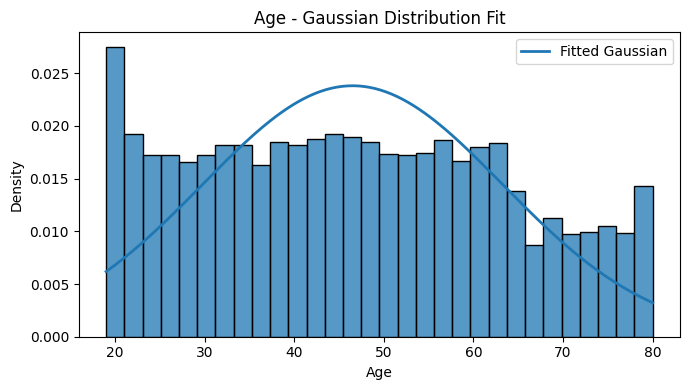

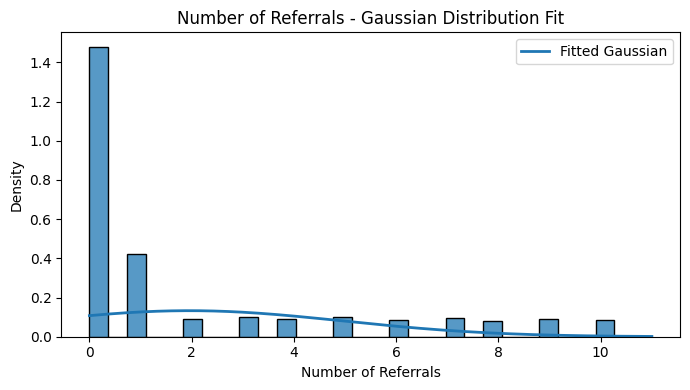

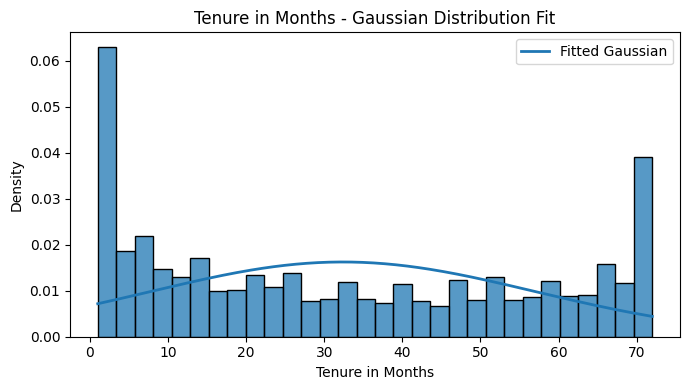

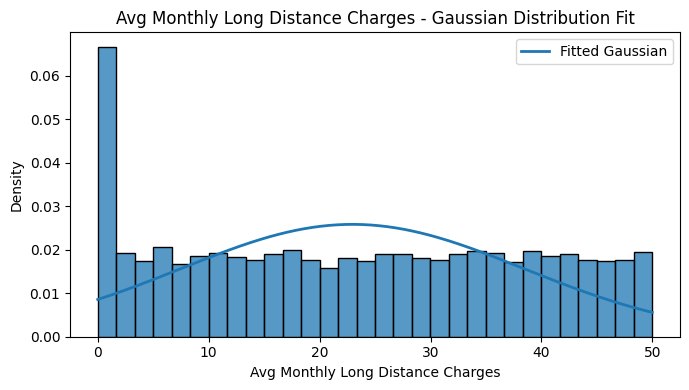

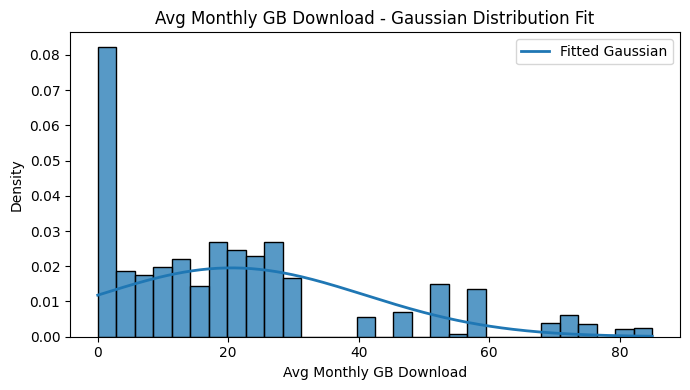

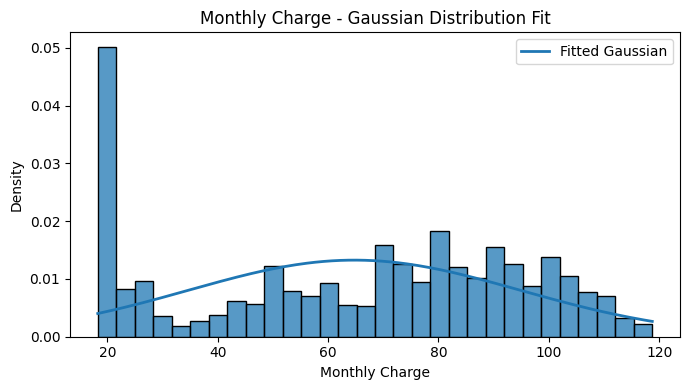

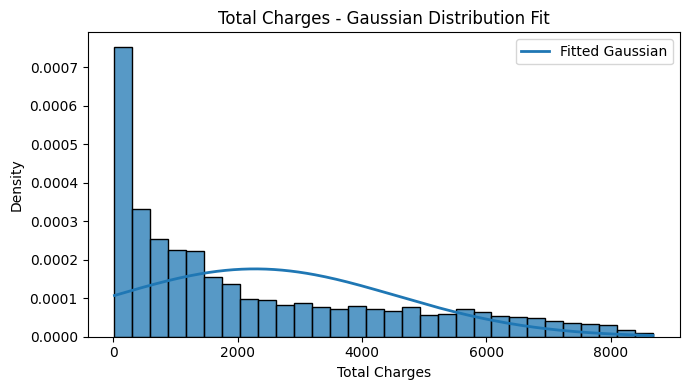

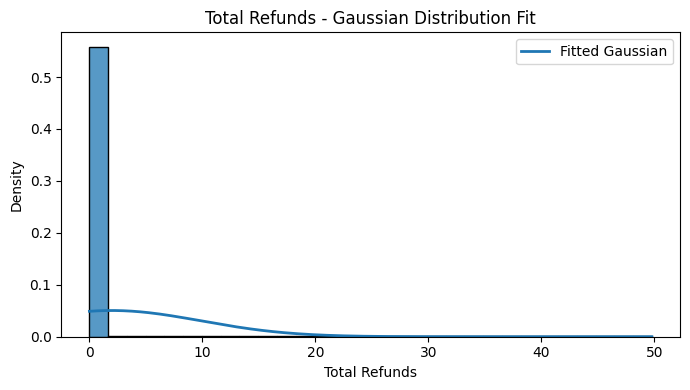

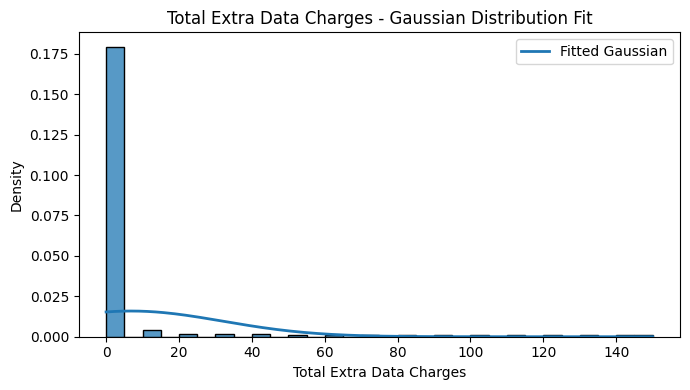

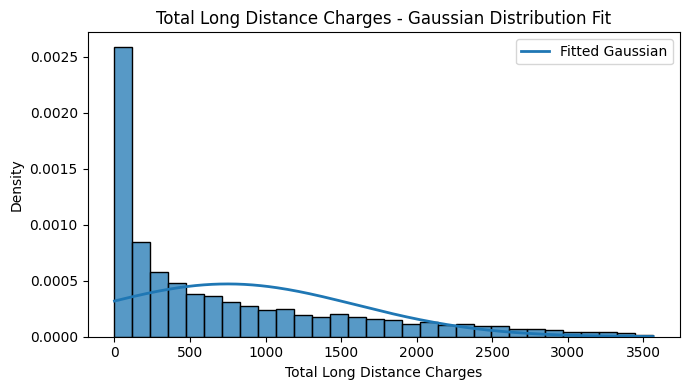

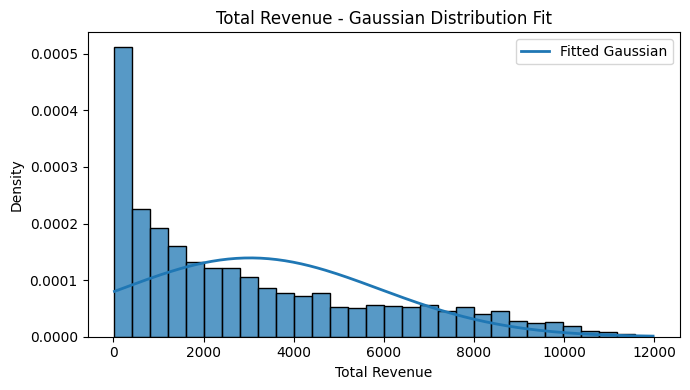

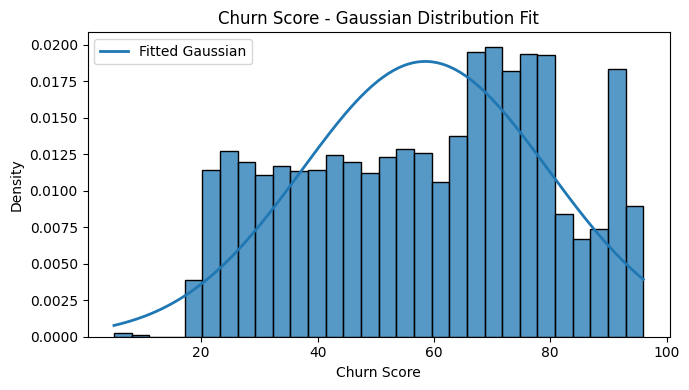

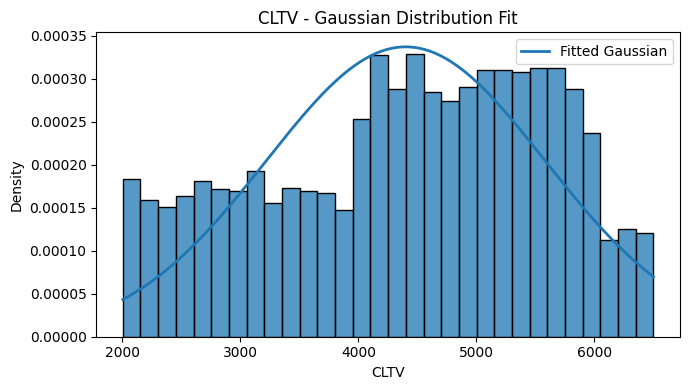

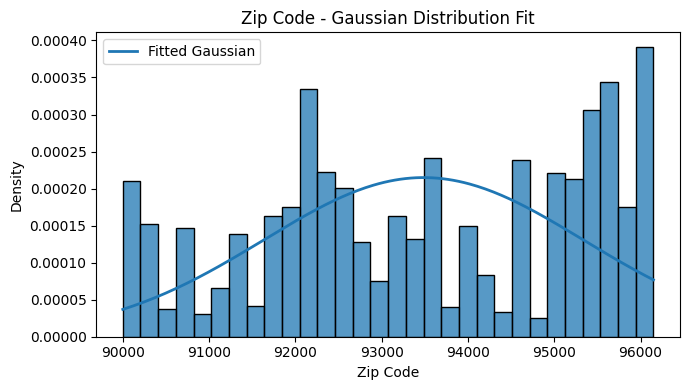

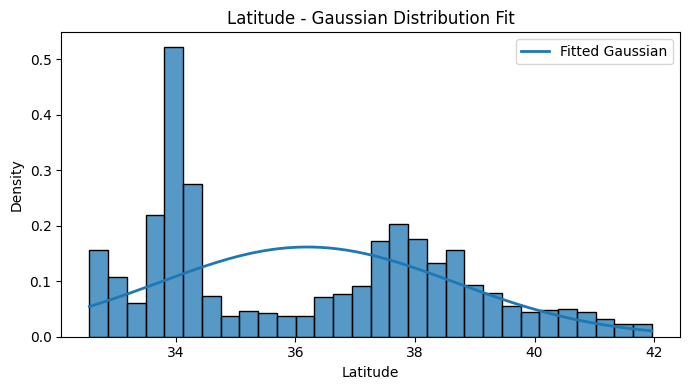

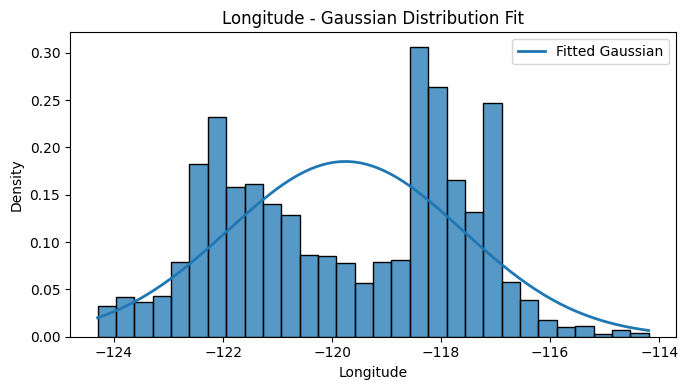

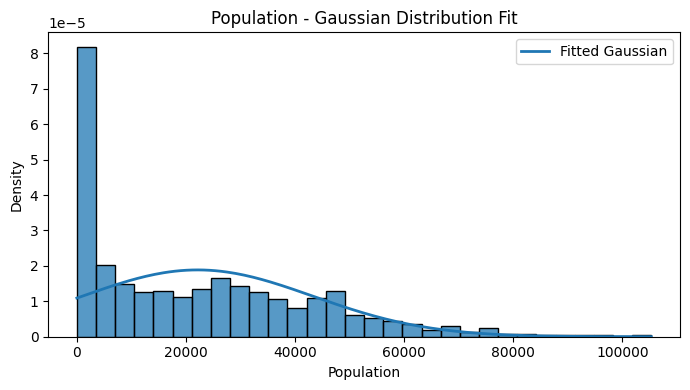

,Feature,Mean (μ),Std (σ),Normality p-value,Approximately Gaussian
0,Age,46.509726,16.749162,5.901070e-266,No
1,Number of Referrals,1.951867,3.000986,6.128989e-221,No
2,Tenure in Months,32.386767,24.540319,0.000000e+00,No
3,Avg Monthly Long Distance Charges,22.958954,15.447017,0.000000e+00,No
4,Avg Monthly GB Download,20.515405,20.417491,5.069183e-186,No
5,Monthly Charge,64.761692,30.087911,0.000000e+00,No
6,Total Charges,2280.381264,2266.059572,8.929567e-125,No
7,Total Refunds,1.962182,7.902053,0.000000e+00,No
8,Total Extra Data Charges,6.860713,25.103196,0.000000e+00,No
9,Total Long Distance Charges,749.099262,846.599946,3.107931e-188,No


In [37]:
# ============================================================
# GAUSSIAN FIT + VISUALIZATION
# ============================================================

gaussian_results = []

for col in continuous_cols:

    data = master_df[col].dropna()

    # Fit Gaussian distribution
    mu, sigma = norm.fit(data)

    # Normality test
    sample = data.sample(
        min(len(data), 5000),
        random_state=42
    )

    stat, p = normaltest(sample)

    gaussian_results.append({
        "Feature": col,
        "Mean (μ)": mu,
        "Std (σ)": sigma,
        "Normality p-value": p,
        "Approximately Gaussian": "Yes" if p > 0.05 else "No"
    })

    # Visualization
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data,
        bins=30,
        stat="density",
        kde=False
    )

    x = np.linspace(
        data.min(),
        data.max(),
        200
    )

    pdf = norm.pdf(
        x,
        mu,
        sigma
    )

    plt.plot(
        x,
        pdf,
        linewidth=2,
        label="Fitted Gaussian"
    )

    plt.title(f"{col} - Gaussian Distribution Fit")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


gaussian_df = pd.DataFrame(gaussian_results)

gaussian_df

In [38]:
# ============================================================
# DISCRETE / COUNT FEATURES
# ============================================================

count_cols = [
    "Number of Referrals",
    "Number of Dependents"
]

count_cols = [
    col for col in count_cols
    if col in master_df.columns
]

for col in count_cols:
    print("\n", col)
    print(master_df[col].value_counts().sort_index())


 Number of Referrals
Number of Referrals
0     3821
1     1086
2      236
3      255
4      236
5      264
6      221
7      248
8      213
9      238
10     223
11       2
Name: count, dtype: int64

 Number of Dependents
Number of Dependents
0    5416
1     553
2     531
3     517
4       9
5      10
6       3
7       2
8       1
9       1
Name: count, dtype: int64


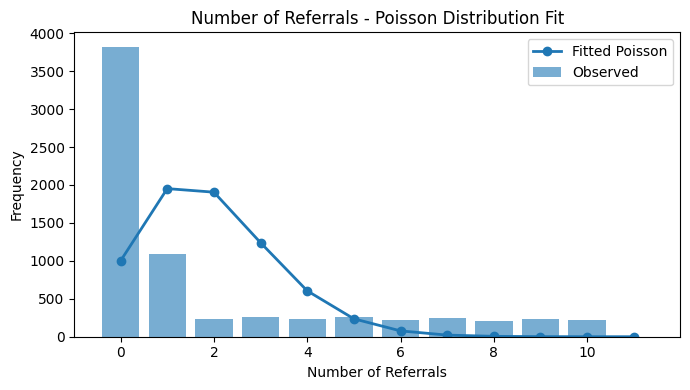

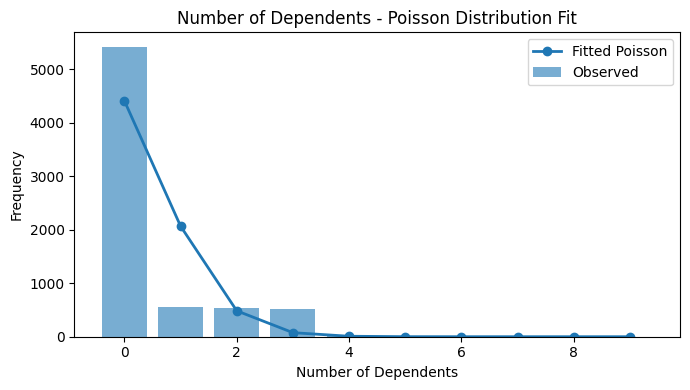

,Feature,Lambda (λ),Chi-square,p-value,Approximately Poisson
0,Number of Referrals,1.951867,23234.131586,0.0,No
1,Number of Dependents,0.468692,3927.625293,0.0,No


In [39]:
# ============================================================
# POISSON FIT + VISUALIZATION
# ============================================================

from scipy.stats import poisson, chisquare

poisson_results = []

for col in count_cols:

    data = master_df[col].dropna().astype(int)

    # Poisson parameter = mean
    lam = data.mean()

    observed = data.value_counts().sort_index()

    # Expected Poisson frequencies
    expected = (
        poisson.pmf(
            observed.index,
            lam
        ) * len(data)
    )

    # Remove categories with extremely small expected values
    mask = expected >= 5

    observed_test = observed[mask]
    expected_test = expected[mask]

    # Rescale expected values
    expected_test = (
        expected_test *
        observed_test.sum() /
        expected_test.sum()
    )

    chi_stat, p = chisquare(
        observed_test.values,
        expected_test
    )

    poisson_results.append({
        "Feature": col,
        "Lambda (λ)": lam,
        "Chi-square": chi_stat,
        "p-value": p,
        "Approximately Poisson": "Yes" if p > 0.05 else "No"
    })

    # Visualization
    plt.figure(figsize=(7, 4))

    values = np.arange(
        data.min(),
        data.max() + 1
    )

    observed_counts = data.value_counts()

    plt.bar(
        values,
        [
            observed_counts.get(v, 0)
            for v in values
        ],
        alpha=0.6,
        label="Observed"
    )

    poisson_expected = (
        poisson.pmf(values, lam) *
        len(data)
    )

    plt.plot(
        values,
        poisson_expected,
        marker="o",
        linewidth=2,
        label="Fitted Poisson"
    )

    plt.title(f"{col} - Poisson Distribution Fit")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()


poisson_df = pd.DataFrame(poisson_results)

poisson_df

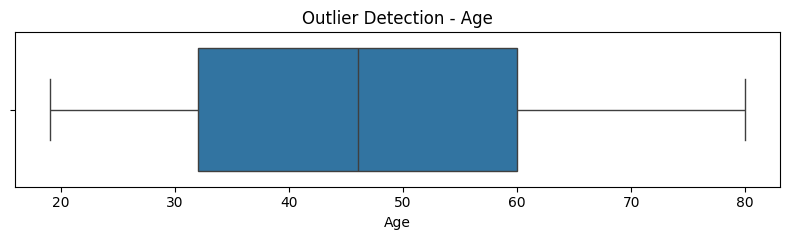

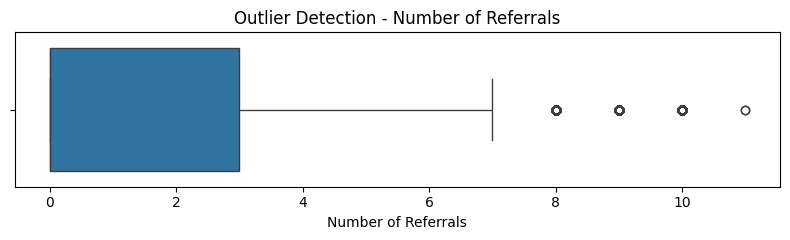

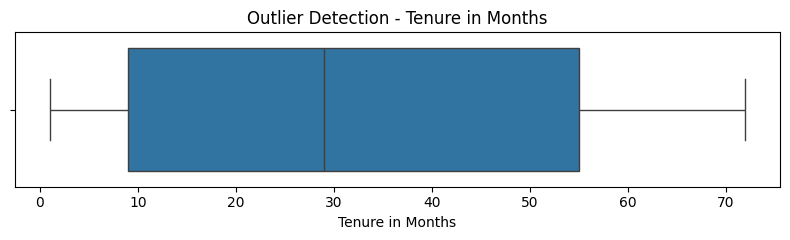

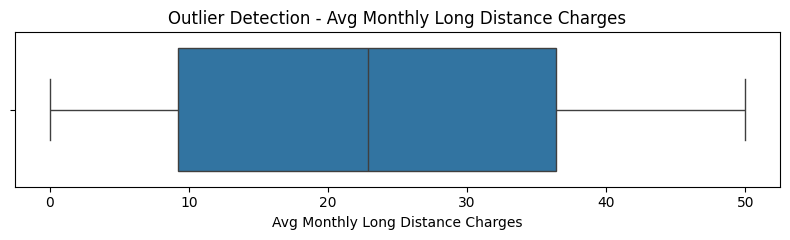

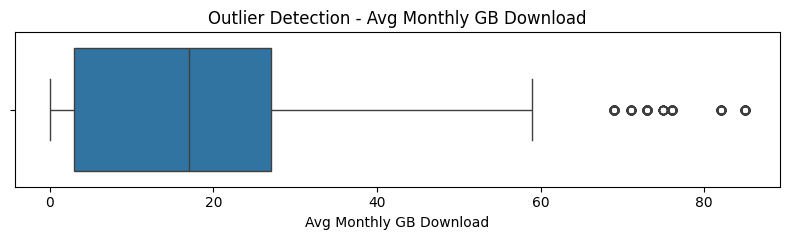

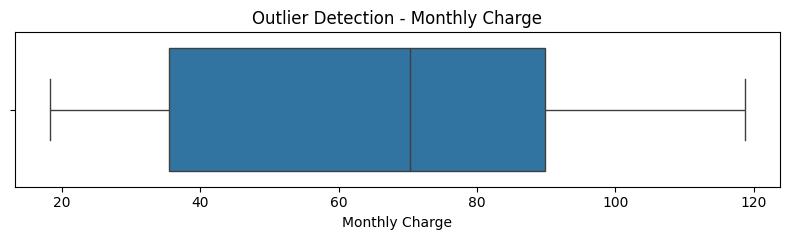

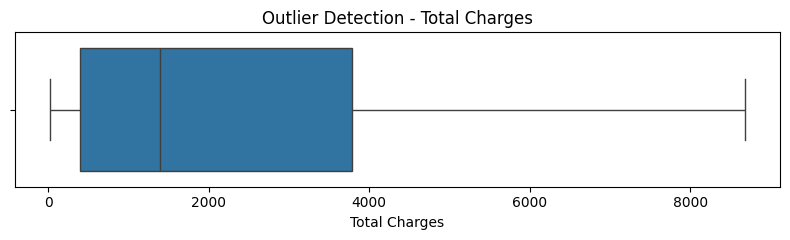

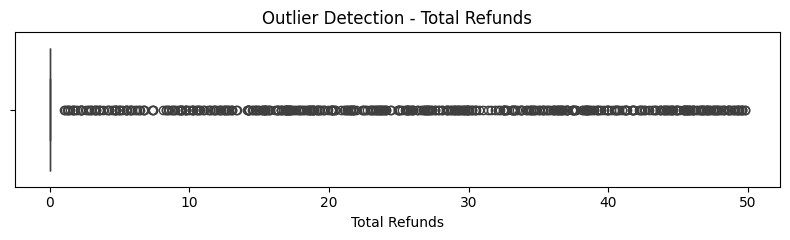

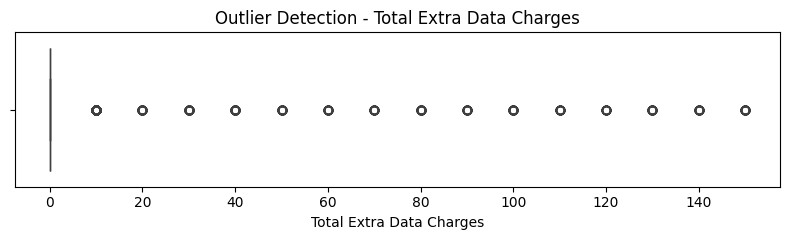

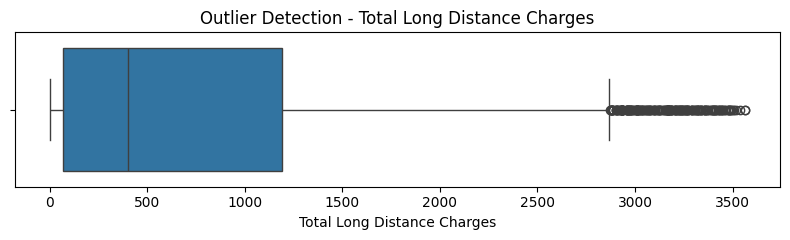

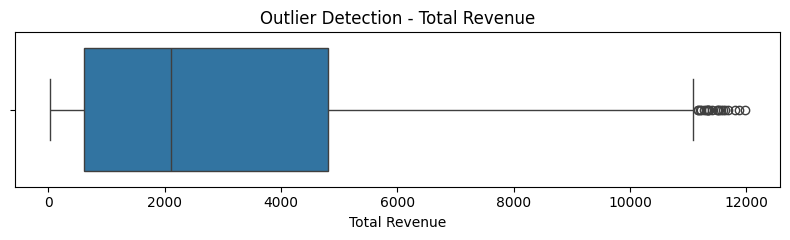

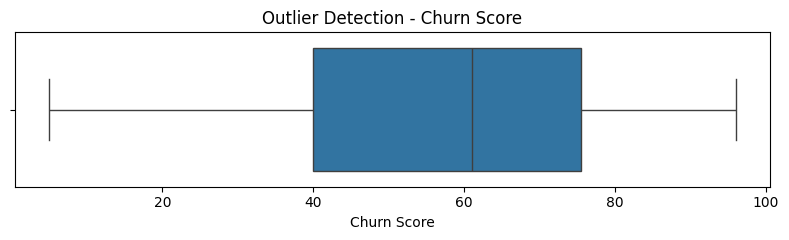

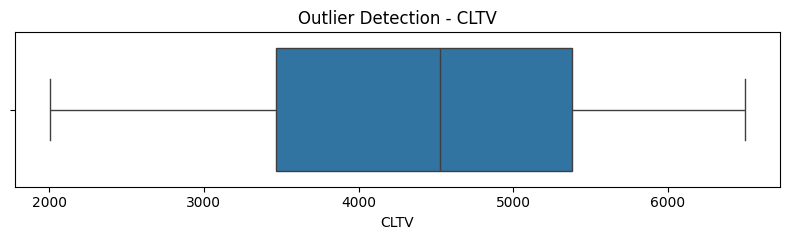

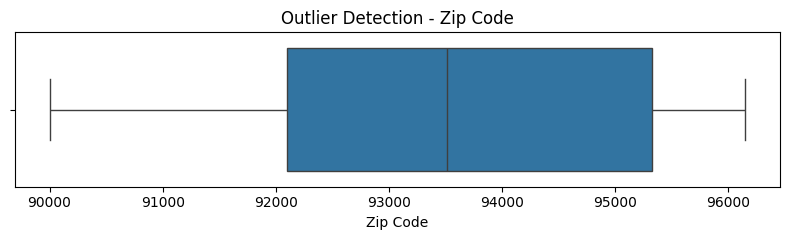

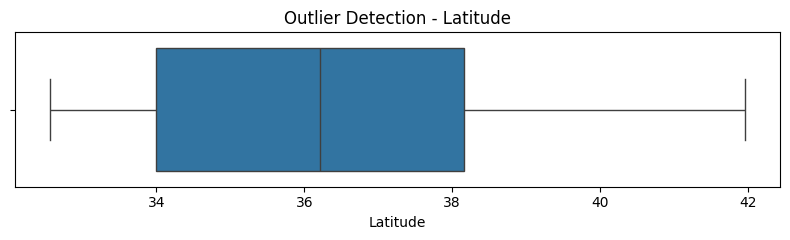

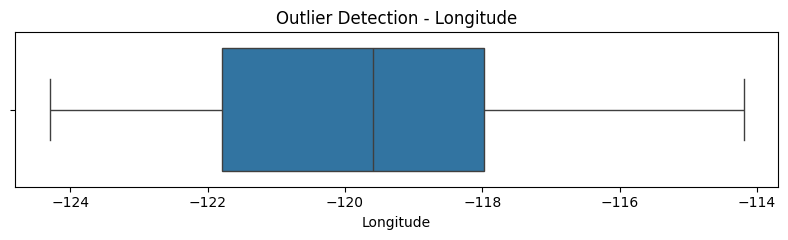

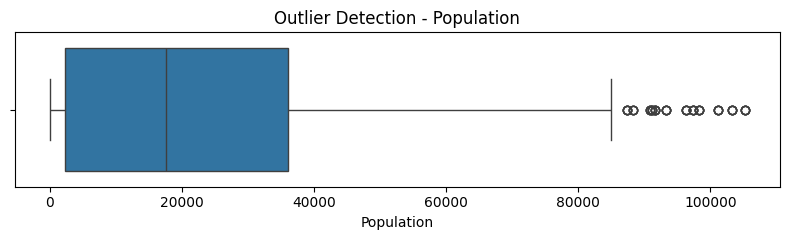

In [40]:
# ============================================================
# OUTLIER DETECTION
# ============================================================

for col in continuous_cols:

    plt.figure(figsize=(8, 2.5))

    sns.boxplot(
        x=master_df[col]
    )

    plt.title(f"Outlier Detection - {col}")
    plt.tight_layout()
    plt.show()

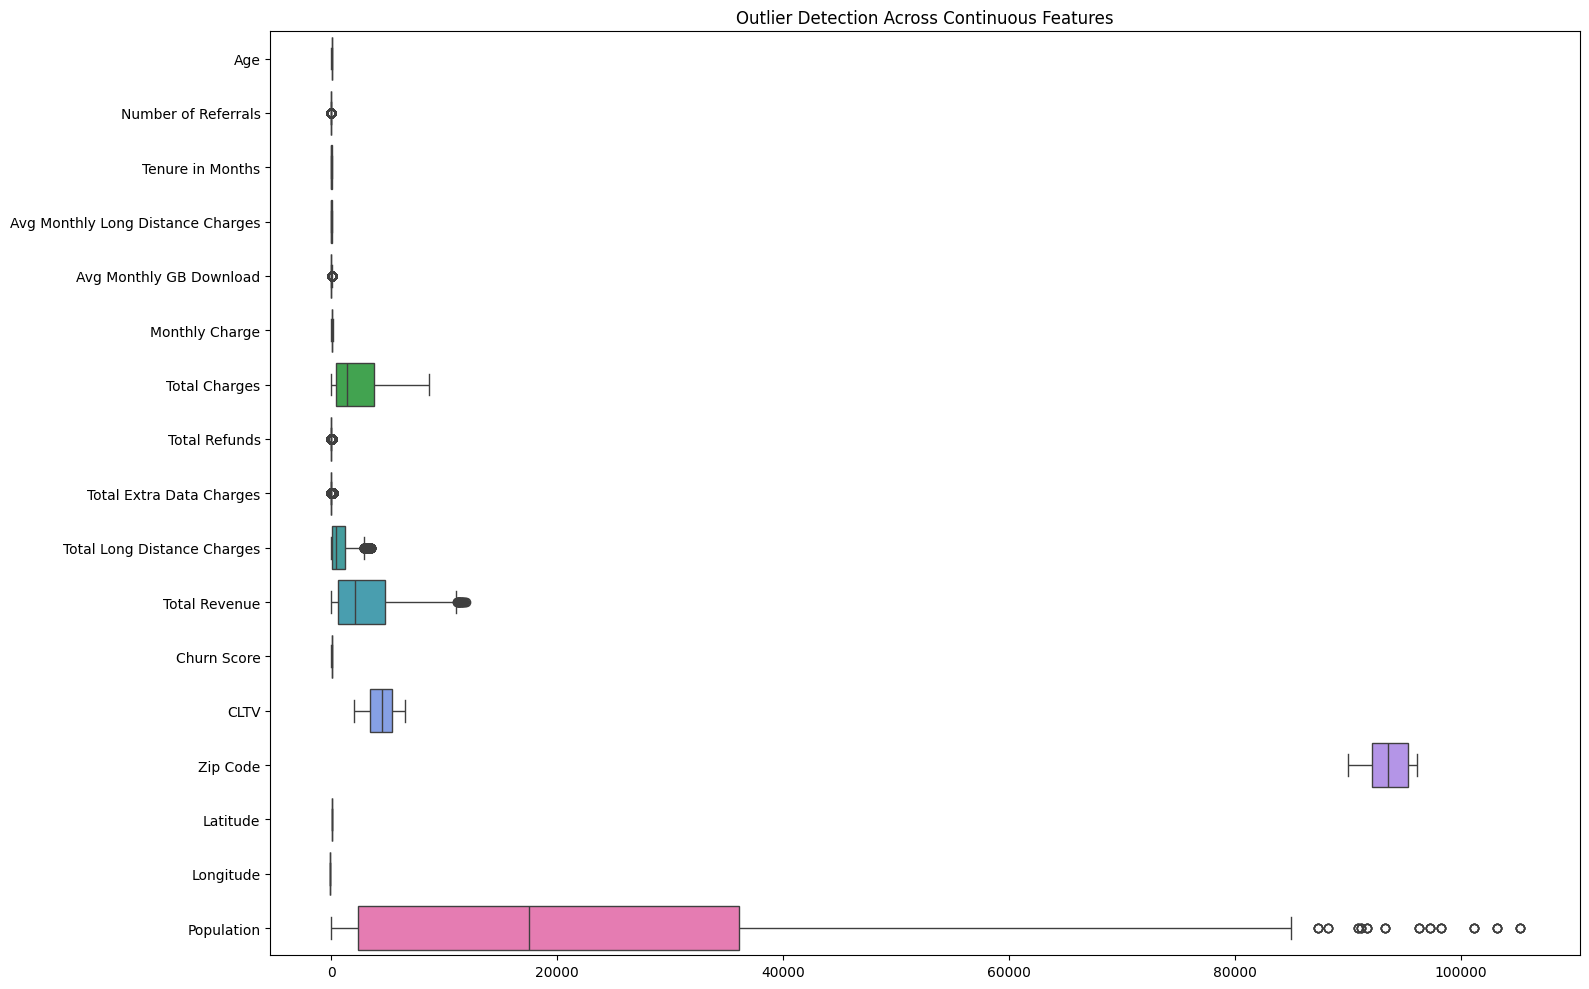

In [41]:
plt.figure(figsize=(16, 10))

sns.boxplot(
    data=master_df[continuous_cols],
    orient="h"
)

plt.title("Outlier Detection Across Continuous Features")
plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# FINAL DISTRIBUTION SUMMARY
# ============================================================

print("GAUSSIAN FIT RESULTS")
display(
    gaussian_df.round(4)
)

print("\nPOISSON FIT RESULTS")
display(
    poisson_df.round(4)
)

GAUSSIAN FIT RESULTS


,Feature,Mean (μ),Std (σ),Normality p-value,Approximately Gaussian
0,Age,46.5097,16.7492,0.0,No
1,Number of Referrals,1.9519,3.0010,0.0,No
2,Tenure in Months,32.3868,24.5403,0.0,No
3,Avg Monthly Long Distance Charges,22.9590,15.4470,0.0,No
4,Avg Monthly GB Download,20.5154,20.4175,0.0,No
5,Monthly Charge,64.7617,30.0879,0.0,No
6,Total Charges,2280.3813,2266.0596,0.0,No
7,Total Refunds,1.9622,7.9021,0.0,No
8,Total Extra Data Charges,6.8607,25.1032,0.0,No
9,Total Long Distance Charges,749.0993,846.5999,0.0,No



POISSON FIT RESULTS


,Feature,Lambda (λ),Chi-square,p-value,Approximately Poisson
0,Number of Referrals,1.9519,23234.1316,0.0,No
1,Number of Dependents,0.4687,3927.6253,0.0,No


Hypothesis Testing

In [43]:
# T Test

from scipy.stats import ttest_ind

churned = master_df[
    master_df["Churn Label"] == "Yes"
]["Monthly Charge"]

stayed = master_df[
    master_df["Churn Label"] == "No"
]["Monthly Charge"]

t_stat, p = ttest_ind(
    churned,
    stayed,
    equal_var=False
)

print("T-statistic:", t_stat)
print("p-value:", p)

if p < 0.05:
    print("Significant difference in Monthly Charge between churn groups")
else:
    print("No significant difference")

T-statistic: 18.407526676414655
p-value: 8.592449331549745e-73
Significant difference in Monthly Charge between churn groups


In [44]:
# Chi- Square Test

from scipy.stats import chi2_contingency

table = pd.crosstab(
    master_df["Contract"],
    master_df["Churn Label"]
)

print(table)

chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-square:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Contract and Churn are significantly associated")
else:
    print("No significant association")

Churn Label       No   Yes
Contract                  
Month-to-Month  1955  1655
One Year        1384   166
Two Year        1835    48

Chi-square: 1445.2932428377585
p-value: 0.0
Contract and Churn are significantly associated


In [45]:
# ANOVA

from scipy.stats import f_oneway

groups = [
    group["Monthly Charge"].dropna()
    for _, group in master_df.groupby("Contract")
]

f_stat, p = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p)

if p < 0.05:
    print("Monthly Charge differs significantly across Contract groups")
else:
    print("No significant difference")

F-statistic: 7.648370067700696
p-value: 0.0004807934627484918
Monthly Charge differs significantly across Contract groups


Document EDA Insights

In [46]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print("\nDataset Shape:", master_df.shape)

print("\nClass Distribution:")
print(master_df["Churn Label"].value_counts())

print("\nClass Percentage:")
print(
    master_df["Churn Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTop Correlations:")
print(corr_pairs.head(10))

print("\nTop Features With Outliers:")
print(outlier_df.head(10))

print("\nMost Skewed Features:")
print(distribution_summary.head(10))

EDA SUMMARY

Dataset Shape: (7043, 47)

Class Distribution:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Class Percentage:
Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Top Correlations:
Total Revenue     Total Charges       0.972212
Total Charges     Total Revenue       0.972212
Latitude          Zip Code            0.894769
Zip Code          Latitude            0.894769
Latitude          Longitude          -0.885979
Longitude         Latitude           -0.885979
Total Revenue     Tenure in Months    0.853146
Tenure in Months  Total Revenue       0.853146
Total Charges     Tenure in Months    0.826074
Tenure in Months  Total Charges       0.826074
dtype: float64

Top Features With Outliers:
                        Feature  Outlier Count  Outlier %
1          Number of Dependents           1627      23.10
12           Satisfaction Score            922      13.09
9      Total Extra Data Charges            728      10.34
2           Number of R